# 1.中间件概述

在 create_agent() 的底层运行机制中，有几个重要的组件，分别是：
- 模型(Model) ：Agent 的“大脑”，负责理解任务与决策推理。
- 工具(Tools) ：Agent 的“手脚”，执行模型自己做不到的外部操作。
- 系统提示词(System Prompt) ：Agent的“角色”，告诉模型该怎么想、参考什么上下文。
- 中间件(Middleware) ：Agent的“中枢”，在执行流程的关键节点进行拦截、控制和增强。  

声明如下：

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware

agent = create_agent(
    model="gpt-5.4-mini",
    tools=[...],
    middleware=[
        SummarizationMiddleware(...),
        HumanInTheLoopMiddleware(...)
    ],
)

## 1.1 什么是中间件
Middleware(中间件)，简单说就是Agent 执行过程中的钩子函数，是 LangChain 1.x 的“王牌”工程化能力。  
- 钩子是框架或系统在某些关键执行点暴露的扩展接口。开发者可以“挂上”自己的逻辑，在那些点上插入、修改或替换行为，而无需改变主流程代码。就像在流水线上某个环节设置了一个“检查点”或“插入器”。  

借助中间件，开发者可以高度定制和控制Agent运行的每一个环节，是处理 Agent 生命周期的标准方式。  

情况1：没有中间件的Agent架构：
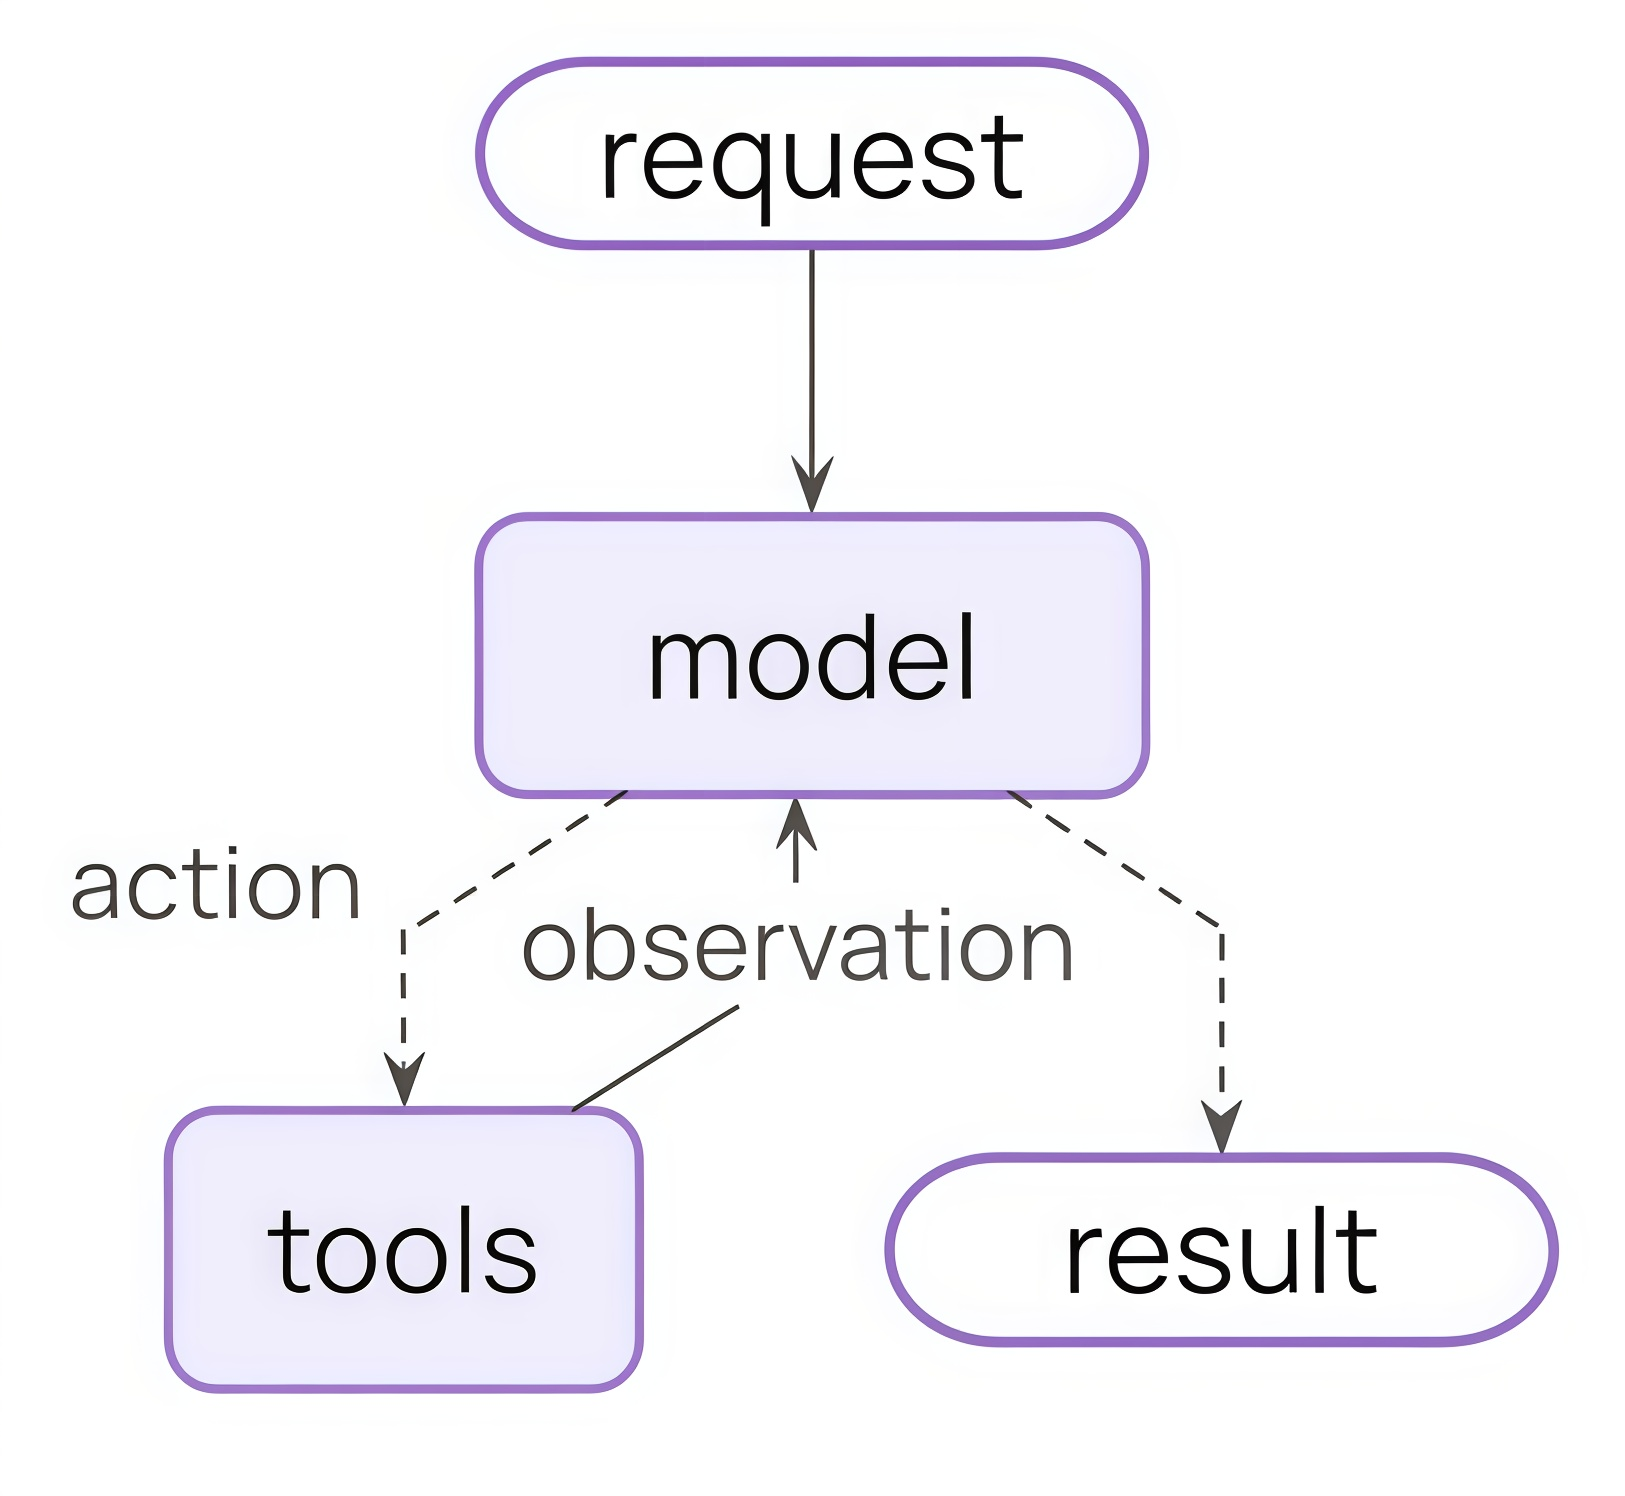

情况2：添加中间件之后的Agent架构变为：  

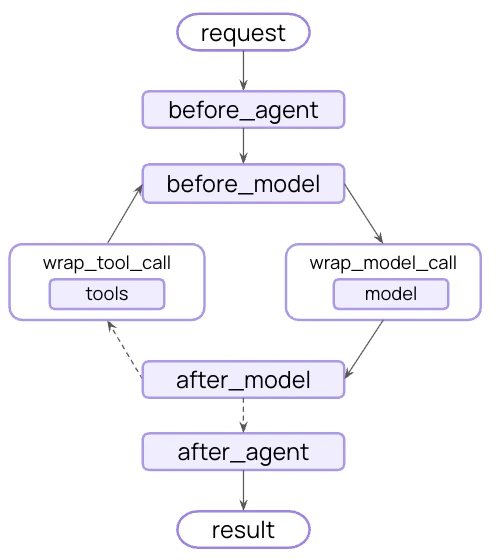

在 LangChain 的 Agent 执行循环中，比如 “模型调用前”、“模型调用后”、“工具调用前后” 设置一些钩子（hooks），让你在不改 Agent 主体逻辑的情况下实现策略与治理。

## 1.2 为什么需要中间件
如果没有中间件，Agent 的执行流程通常比较直接：  
**用户输入 → 拼接提示词/消息 → 调用模型 → 如有需要调用工具 → 返回结果**

这种方式对于简单场景已经足够，但一旦进入真实项目，往往会遇到很多额外需求，例如：
- 想根据问题复杂度动态切换模型；
- 想限制某些用户只能调用部分工具；
- 想在工具报错时自动重试或返回兜底结果；
- 想在模型调用前插入额外的系统提示；
- 想记录每一步的执行日志，方便排查问题；
- 想在敏感信息出现时阻断执行；
- 想在正式执行工具前增加人工审批。

这些需求有一个共同特点：它们不是 Agent 的核心业务逻辑，但又会影响 Agent 的执行过程。如果把这些逻辑全部直接写进主流程，会带来几个问题：

**1）主流程会迅速变乱**  
Agent 本身只需要关心“理解用户需求、决定是否调用工具、生成结果”，
但一旦把日志、鉴权、重试、风控、审计都塞进去，主逻辑就会变得臃肿。

**2）很多逻辑是横切需求，难以复用**  
例如日志、重试、风控、权限控制，通常不是某一个 Agent 独有的，而是多个 Agent 都需要。如果直接
写死在每个 Agent 里，会产生大量重复代码。

**3）流程控制粒度不够细**  
有些逻辑必须发生在“模型调用前”，有些要发生在“工具调用后”，如果没有统一的执行拦截点，开发者只
能手动改主流程，既麻烦又容易出错。

**4）后期维护成本高**  
当你需要增加一个新规则，例如“所有外部工具调用前都先做审计”，如果系统没有中间件机制，往往需
要修改很多处代码。

总结：  
中间件的价值就在于把这些与业务无关、但与执行过程强相关的横切逻辑，从 Agent 主流程中分离出来。让Agent 主体代码聚焦业务，而借助中间件，实现“ 拦截流程、修改流程、增强流程”。

简言之，LangChain 1.x 的中间件能实现如下功能：  
✅ 日志与分析 - 追踪行为、调试、性能监控  
✅ 转换 - 修改提示词、工具选择、输出格式  
✅ 容错 - 重试、降级、早期终止  
✅ 安* - 限流、守护规则、PII 检测  

## 1.3 中间件的分类
根据LangChain是否已经定义了来分类：
- **自定义中间件**：允许开发者自定义，从而实现更加灵活的Agent行为管理
- **内置中间件**：LangChain实现并提供的
    - 模型供应商定制的中间件：依赖于特定模型服务的实现（不是本课的重点）
    - 和模型供应商无关的中间件。LangChain提供的与供应商无关的中间件如下：  
链接：https://docs.langchain.com/oss/python/langchain/middleware/overview

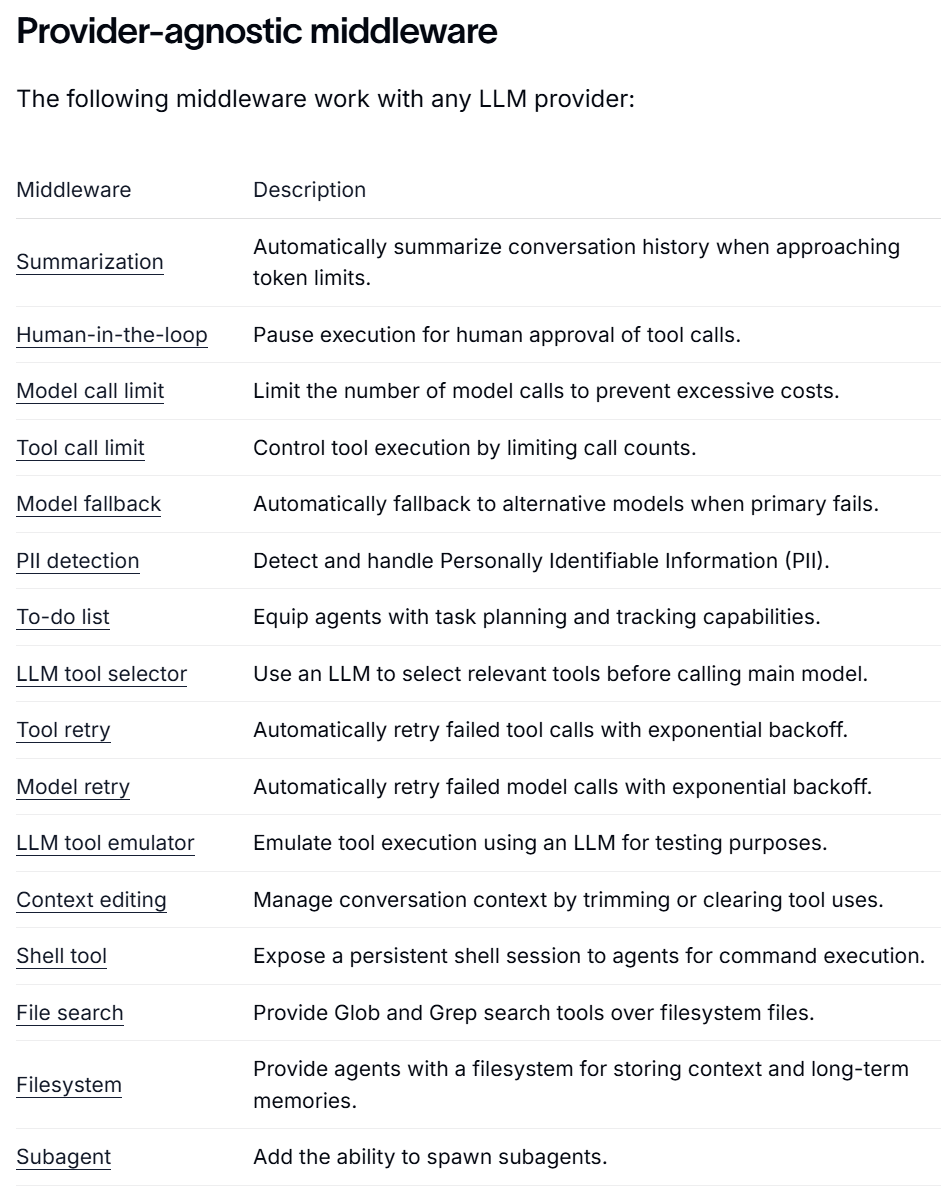

## 1.4 和模型供应商无关的内置中间件分类
LangChain提供的和模型供应商无关的内置中间件分为六个类别  
### 类型1：成本与资源控制类
核心目标：控成本、控配额、避免无限调用  
这类中间件主要解决“ Agent太贵、太能跑、停不下来”的问题。  
包含：
- **Model call limit**：限制模型调用次数，防止一次任务反复请求 LLM，导致费用失控
- **Tool call limit**：限制工具调用次数，避免 Agent 无限试错、死循环调工具
- **Summarization**：在上下文快满时自动总结历史，减少 token 消耗
- **Context editing**：裁剪上下文、清理工具调用痕迹，本质上也是为了节省上下文成本

业务场景理解：  
适合生产环境的成本治理、配额治理、长会话优化、SaaS 产品控费。

### 类型2：稳定性与容错保障类
核心目标：保证服务不中断、失败后尽量自动恢复  
这类中间件主要解决“ 调用失败怎么办、模型挂了怎么办、工具超时怎么办”。  
包含：  
- **Model fallback**：主模型失败时切换备用模型
- **Model retry**：模型调用失败后自动重试
- **Tool retry**：工具调用失败后自动重试


业务场景理解：  
适合线上生产系统，尤其是多模型、多工具依赖的 Agent。  
本质上是在做 高可用、容灾、鲁棒性建设。

### 类型3：安全与合规风控类
核心目标：让 Agent 可控、可审、合规  
这类中间件主要解决“ Agent乱执行、泄露敏感信息、做危险操作”的问题。  
包含：
- **Human-in-the-loop**：在关键工具调用前暂停，等人工审批
- **PII detection**：检测和处理个人敏感信息
- **Model call limit / Tool call limit**：某种意义上也可归到风控，因为它能防止异常滥用


业务场景理解：  
适合企业内部系统、客服系统、审批流、数据查询类 Agent。  
尤其是涉及：发邮件、调数据库、调财务/人事系统、导出敏感信息、执行外部动作等

### 类型4：决策增强与智能编排类
核心目标：提升 Agent 的决策质量和任务拆解能力  
这类中间件主要解决“ Agent不够聪明、不会规划、不会先筛工具”的问题。  
包含：  
- **To-do list**：给 Agent 增加任务规划、分步骤执行和状态跟踪能力
- **LLM tool selector**：当工具太多时，用子模型筛选最相关的几个工具交给主模型
- **Subagent**：允许生成子Agent，把复杂任务拆给不同角色处理


业务场景理解：  
适合复杂任务流，比如：研究型 Agent、多步骤分析、报告生成、多角色协作、长链路任务编排等。  
这类本质上是在增强 Agent的“脑子”与“组织能力”。

### 类型5：执行能力扩展类
核心目标：给 Agent 更多“手脚”  
这类中间件主要解决“ Agent只能聊天，不能真正操作环境”的问题。  
包含：  
- **Shell tool**：给 Agent 持久 shell，会执行命令
- **File search**：给 Agent 文件搜索能力，能做 Glob/Grep
- **Filesystem**：给 Agent 文件系统读写与长期存储能力


业务场景理解：  
适合工程 Agent、代码 Agent、本地自动化 Agent、运维 Agent。  
本质上是把 Agent 从“纯推理”扩展成“能操作环境的执行体”。

### 类型6：开发调试与测试辅助类
核心目标：方便开发、测试、验证 Agent 行为  
这类中间件主要不是直接服务业务，而是服务于研发和调试阶段。  
包含：  
- **LLM tool emulator**：用 LLM 模拟工具执行，便于测试（最典型）
- **Summarization**：有时也可辅助调试长会话表现
- **Context editing**：可用于测试上下文裁剪效果
- **Human-in-the-loop**：也常用于调试高风险步骤


业务场景理解：  
适合开发阶段快速验证流程、做 mock、减少真实工具依赖。

# 2、常用内置中间件的使用
LangChain 1.0 提供了 16 个预置中间件，开箱即用。  
我们不会逐个介绍上述与模型供应商无关的所有内置中间件，这里将与模型供应商无关的内置中间件分成两部分：   
常用内置中间件（本节）， 其它内置中间件（下节）。  
第一部分将会详细讲解，第二部分提供测试代码和结果，快速演示。  

## 2.1 SummarizationMiddleware中间件
作用：对历史消息列表进行摘要&总结，达到压缩上下文的效果。  
原理：在达到触发条件时，调用大模型对历史消息进行摘要， 将摘要的结果作为HumanMessage ，放到消息列表最开始的位置。

### 2.1.1 参数说明
注意：本节中间件的参数说明不保证包含完整参数列表，不常用或被标记为过时的参数被省略。
#### 参数1：model —用于摘要的模型
可以是模型名称也可以是模型对象，如果传递的是模型名称，底层会调用init_chat_model 初始化模型。
#### 参数2：trigger —摘要触发条件
是一个列表，每个元素对应一个条件，当任一条件满足时，触发摘要。
1. tokens ：token的数量，历史token的累计数量达到该值触发摘要。
2. messages ：历史消息数量，历史消息条数达到该值触发摘要。
3. fraction ：上下文长度比例。历史token的累计数量达到模型的max_input_tokens*fraction 触发摘要

如果条件包含fraction ，要求模型的profile包含max_input_tokens ，Deepseek模型的profile为空，此时需要手动添加该配置项。Deepseek-V3.2的上下文长度为128K。

#### 参数3：keep —摘要时保留的原始消息
支持三种条件，但和trigger不同，keep同一时间只接收一种条件。  
1. tokens ：摘要时保留的token数量。
2. messages ：摘要时保留的历史消息条数。
3. fraction ：摘要时保留max_input_tokens*fraction 个token。

#### 参数4：token_counter —统计token数量的函数
默认使用LangChain提供的count_tokens_approximately ，一般不用更改。  
    对于纯文本消息，该函数的大致思路是先统计消息的字符数，也就是len(字符串) ，然后再除以每个token大致的字符数，转换为粗略的token数，再加一些额外开销。作为估算的token数。
#### 参数5：summary_prompt —摘要时的自定义提示词
该提示词需要包含{messages} 占位符，使得历史消息列表可以被插入。不指定则使用内置提示词。
#### 参数6：trim_token_to_summarize —摘要时历史消息的最大token数
如果历史消息token数大于该值，则会被裁剪。默认为" 4000 "。  
如果trigger用token作为度量，调大触发阈值时，当前配置项应相应调整，否则会丢失信息。

### 2.1.2 举例1 测试trigger、keep参数

In [1]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
custom_profile = {
    "max_input_tokens": 128_000
}

model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    profile=custom_profile,
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

后续代码：

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("你是个非常友好的AI助手"),
    HumanMessage("你好啊，我是老王，你是谁？"),
    AIMessage("你好老王，我是小王"),
    HumanMessage("好的小王，很高兴认识你"),
    AIMessage("你高兴得太早了"),
    HumanMessage("呵呵，你什么意思")
]

agent = create_agent(
    model="deepseek-v4-flash",
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=[
                ("tokens", 100),
                ("messages", 6),
                ("fraction", 0.001)
            ],
            keep=("messages", 2)
        )
    ]
)

response = agent.invoke({
    "messages": messages
})

for msg in response["messages"]:
    msg.pretty_print()

c:\Users\huan.zheng\AppData\Local\miniconda3\envs\langchain1\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


================================ Human Message =================================

Here is a summary of the conversation to date:

## SESSION INTENT
The user (who calls themselves 老王) opened a friendly introduction session with the AI, asking who it is and establishing how they should address each other.

## SUMMARY
- The human user identified themselves as "老王" (Old Wang).
- The AI introduced itself as "小王" (Little Wang).
- The human user acknowledged the introduction and expressed pleasure in meeting the AI ("很高兴认识你").
- The relationship is cordial and informal; the user is friendly.

## ARTIFACTS
None

## NEXT STEPS
None — the introduction was completed successfully. Future conversation can continue in a friendly tone, with the AI addressed as "小王" and the user as "老王".
================================== Ai Message ==================================

你高兴得太早了
================================ Human Message =================================

呵呵，你什么意思
================================== A

分析：
1. 我们通过自定义profile指定了max_input_tokens，才能用fraction作为度量，否则报错。
2. 三个条件触发条件至少有一个满足，触发了摘要。
3. 摘要结果作为HumanMessage，传入消息列表头部
4. keep要求保留两条消息，则最新两条消息原样保留。

### 2.1.3 举例2 测试summary_prompt参数

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

custom_profile = {
    "max_input_tokens": 1_000_000
}

model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    profile=custom_profile,
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

messages = [
    SystemMessage("你是个非常有好的AI助手"),
    HumanMessage("你好啊，我是老王，你是谁？"),
    AIMessage("你好老王，我是小王"),
    HumanMessage("好的小王，很高兴认识你"),
    AIMessage("你高兴得太早了"),
    HumanMessage("呵呵，你什么意思，你是谁？")
]

agent = create_agent(
    model="deepseek-v4-flash",
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=[
                ("tokens", 100),
                ("messages", 6),
                ("fraction", 0.0001)
            ],
            keep=("messages", 2),
            summary_prompt="对历史消息摘要，消息列表如下\n{messages}"
        )
    ]
)

response = agent.invoke({
    "messages": messages
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

摘要：老王向AI助手问好并自我介绍，AI助手自称小王，双方愉快认识。
================================== Ai Message ==================================

你高兴得太早了
================================ Human Message =================================

呵呵，你什么意思，你是谁？
================================== Ai Message ==================================

呵呵，别误会，我是小王啊，就是你刚才认识的那个AI助手。你刚才先说“你高兴得太早了”，我就跟着回了一句，算是一种调侃——意思是“你也别高兴太早，咱们彼此彼此”。真没别的意思，更不是要抬杠。重新认识一下：我是小王，很高兴认识你！


分析
1. 摘要结果和案例一明显不同，提示词生效了
2. 摘要包含了历史对话记录， {messages} 被替换为历史消息列表。

## 2.2 HumanInTheLoopMiddleware中间件
HumanInTheLoopMiddleware（人在环中间件、人工审核中间件）在工具调用前中断Agent运行，等待用户对工具调用请求决策。可选的决策有： approve（同意执行） 、edit（编辑调用配置后执行） 、reject（拒绝执行） 。
### 2.2.1 参数说明
#### 参数1：interrupt_on —工具名和中断策略的映射
策略可以是True、False或InterruptOnConfig对象，精细控制决策选项。  
比如：

In [ ]:
interrupt_on={
    "get_weather": True,
    "read_email_tool": False,
    "send_email_tool": {
        "allowed_decisions": ["approve", "reject"],
    },
}

1. True表示所有决策(approve, edit, reject) 都可以选择，相当于

In [ ]:
"get_weather": {
    "allowed_decisions": ["approve", "edit", "reject"],
}

2. False表示不中断，即无需审批即可执行。
3. InterruptOnConfig 是一个TypedDict的子类，可以用字典直接赋值。支持的Key有：  
    ① allowed_decisions 精细控制中断后允许的决策。  
    ② description ：特定工具的中断描述信息，优先级高于description_prefix，后者会更改所有工具中断的描述。

#### 参数2：description_prefix —自定义中断描述
默认为"Tool execution requires approval" ，下面的举例可以看到效果。

### 2.2.2 举例过程1：调用前中断
**注意：本例需要从中断的位置让Agent继续运行，这就需要用到短期记忆，这里先使用即可。**   
创建Agent时通过checkpointer参数启用了短期记忆，在调用时通过传递相同的config加载记忆。记住固定用法即可。

In [4]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    profile=custom_profile,
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from langchain.tools import tool
from langgraph.types import Command
from rich import print as rprint
@tool
def get_weather(city: str, is_forcast: bool = False) -> str:
    """
    查询指定城市天气

    Args:
        city: 城市名称
        is_forcast: 是否包含明日天气预报？
    """
    res = f"{city}今天天气不错"
    if is_forcast:
        res += "\n明天下雨"
    return res

@tool
def get_news() -> str:
    """
    查询当日新闻
    """
    return "中方三艘油轮通过霍尔木兹海峡"

@tool
def read_email_tool(email_id: str) -> str:
    """通过邮件ID读取内容的伪函数"""
    return f"邮件ID：{email_id}\n是空的"

@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """发送邮件伪函数"""
    print(">>> 真的执行发送邮件工具了")
    return f"发送给 {recipient} 的邮件标题是：{subject}，内容：{body}"

agent = create_agent(
    model=model,
    tools=[get_weather, get_news, read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
        interrupt_on={
            "get_weather": True,
            "get_news": True,
            "read_email_tool": False,
            "send_email_tool": {
                "allowed_decisions": ["approve", "reject"],
                "description": "发送邮件中断啦"
            },
        },
        description_prefix="中断啦"
        ),
    ],
)

config = {"configurable": {"thread_id": "1"}}

# 第一次调用：会暂停在发送邮件前
response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="请帮我查询今天北京的天气"
                "查询今日新闻"
                "查看ID为 'sk2131421' 的邮件内容，"
                "向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'"
                "同时做这四件事"
            )
        ]
    },
    config=config,
)

print("==== 第一次 invoke 返回 ====")
print("========= 原始响应 =========")
rprint(response)
print("========= 美化输出 =========")
for msg in response["messages"]:
    msg.pretty_print()

# 关键：看中断信息
interrupts = response.get("__interrupt__", [])
print("========== interrupts ==========")
rprint(interrupts)
# print("==== 逐个打印 interrupt 请求 ====")
action_requests = interrupts[0].value["action_requests"]
for action_request in action_requests:
    rprint(action_request)

==== 第一次 invoke 返回 ====
========= 原始响应 =========


{
    'messages': [
        HumanMessage(
            content="请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 
的邮件内容，向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事",
            additional_kwargs={},
            response_metadata={},
            id='1a045b5d-fd29-4798-9585-cfc5615860d1'
        ),
        AIMessage(
            content='好的，我来同时执行这四项操作：查询北京天气、查询今日新闻、读取邮件、发送邮件。',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': "The user wants me to do four things simultaneously:\n1. Query today's weather
in Beijing\n2. Query today's news\n3. Read email with ID 'sk2131421'\n4. Send email to 18701768310@163.com with 
subject '哈哈哈' and body '你好啊'\n\nAll four are independent, so I can call them all at once."
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 266,
                    'prompt_tokens': 595,
                    'total_tokens': 861,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 76,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 595
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '647a1b65-203e-4163-a26d-2bedde200acb',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019ffb71-f9be-7950-ba5b-12e7620e09ce-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_vhfVGGBcbakWnT5yNwZo7686',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_01_m2KIC5ASIZTssyEPgHia6416', 'type': 'tool_call'},
                {
                    'name': 'read_email_tool',
                    'args': {'email_id': 'sk2131421'},
                    'id': 'call_02_dBuhfmqpPuJ2Mup4HlRE7551',
                    'type': 'tool_call'
                },
                {
                    'name': 'send_email_tool',
                    'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
                    'id': 'call_03_ktYa1kR2g0xO4s2frUrG2803',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 595,
                'output_tokens': 266,
                'total_tokens': 861,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 76}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'get_weather',
                        'args': {'city': '北京'},
                        'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
                    },
                    {'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'},
                    {
                        'name': 'send_email_tool',
                        'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
                        'description': '发送邮件中断啦'
                    }
                ],
                'review_configs': [
                    {'action_name': 'get_weather', 'allowed_decisions': ['approve', 'edit', 'reject']},
                    {'action_name': 'get_news', 'allowed_decisions': ['approve

========= 美化输出 =========
================================ Human Message =================================

请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 的邮件内容，向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事
================================== Ai Message ==================================

好的，我来同时执行这四项操作：查询北京天气、查询今日新闻、读取邮件、发送邮件。
Tool Calls:
  get_weather (call_00_vhfVGGBcbakWnT5yNwZo7686)
 Call ID: call_00_vhfVGGBcbakWnT5yNwZo7686
  Args:
    city: 北京
  get_news (call_01_m2KIC5ASIZTssyEPgHia6416)
 Call ID: call_01_m2KIC5ASIZTssyEPgHia6416
  Args:
  read_email_tool (call_02_dBuhfmqpPuJ2Mup4HlRE7551)
 Call ID: call_02_dBuhfmqpPuJ2Mup4HlRE7551
  Args:
    email_id: sk2131421
  send_email_tool (call_03_ktYa1kR2g0xO4s2frUrG2803)
 Call ID: call_03_ktYa1kR2g0xO4s2frUrG2803
  Args:
    recipient: 18701768310@163.com
    subject: 哈哈哈
    body: 你好啊
========== interrupts ==========


[
    Interrupt(
        value={
            'action_requests': [
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
                },
                {'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'},
                {
                    'name': 'send_email_tool',
                    'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
                    'description': '发送邮件中断啦'
                }
            ],
            'review_configs': [
                {'action_name': 'get_weather', 'allowed_decisions': ['approve', 'edit', 'reject']},
                {'action_name': 'get_news', 'allowed_decisions': ['approve', 'edit', 'reject']},
                {'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'reject']}
            ]
        },
        id='dffb97cbe7847008d1cfc896831ba56e'
    )
]

{
    'name': 'get_weather',
    'args': {'city': '北京'},
    'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
}

{'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'}

{
    'name': 'send_email_tool',
    'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
    'description': '发送邮件中断啦'
}

### 2.2.3 举例过程2：指明工具调用请求决策

In [6]:
# 如果有中断，说明进入人在环了
weather_decision = {
    "type": "edit",
    "edited_action": {
        "name": "get_weather",
        "args": {"city": "中国北京市", "is_forcast": True}
    }
}

news_decision = {
    "type": "approve",
}
send_email_decision = {
    "type": "approve"
}
decisions = {
    "decisions": []
}

# 决策的顺序必须和返回的中断请求顺序一致
for action_request in action_requests:
    if action_request["name"] == "get_weather":
        decisions["decisions"].append(weather_decision)
    if action_request["name"] == "get_news":
        decisions["decisions"].append(news_decision)
    if action_request["name"] == "send_email_tool":
        decisions["decisions"].append(send_email_decision)

if interrupts:
    # 审批通过
    resumed_response = agent.invoke(
    Command(resume=decisions),
    config=config, # 必须是同一个 thread_id
    )
    print("==== 审批后继续执行 ====")
    for msg in resumed_response["messages"]:
        msg.pretty_print()

>>> 真的执行发送邮件工具了
==== 审批后继续执行 ====
================================ Human Message =================================

请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 的邮件内容，向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事
================================== Ai Message ==================================

好的，我来同时执行这四项操作：查询北京天气、查询今日新闻、读取邮件、发送邮件。
Tool Calls:
  get_weather (call_00_vhfVGGBcbakWnT5yNwZo7686)
 Call ID: call_00_vhfVGGBcbakWnT5yNwZo7686
  Args:
    city: 中国北京市
    is_forcast: True
  get_news (call_01_m2KIC5ASIZTssyEPgHia6416)
 Call ID: call_01_m2KIC5ASIZTssyEPgHia6416
  Args:
  read_email_tool (call_02_dBuhfmqpPuJ2Mup4HlRE7551)
 Call ID: call_02_dBuhfmqpPuJ2Mup4HlRE7551
  Args:
    email_id: sk2131421
  send_email_tool (call_03_ktYa1kR2g0xO4s2frUrG2803)
 Call ID: call_03_ktYa1kR2g0xO4s2frUrG2803
  Args:
    recipient: 18701768310@163.com
    subject: 哈哈哈
    body: 你好啊
================================= Tool Message =================================
Name: get_weather

中国北京市今天天气不错
明天下雨
========